## **Connect Colab**

In [1]:
#conect with drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.environ["GITHUB_TOKEN"] = "github"
os.environ["KAGGLE_USERNAME"] = "kaggle_username"
os.environ["KAGGLE_KEY"] = "kaggle_key"

In [6]:
!dir /content/drive/MyDrive/apai/resnet50/models/

ResNet50_10C.pth


In [7]:
!sed -i 's/\r$//' /content/drive/MyDrive/apai/fetch_src.sh  # Windows users
!bash /content/drive/MyDrive/apai/fetch_src.sh

 fetch_src.sh — Download /src from GitHub

Checking environment...
GITHUB_TOKEN set
Fetching file list from GitHub API...
Found 15 file(s) under /src/
src/cl_strategies/ewc.py -> /content/src/cl_strategies/ewc.py
src/cl_strategies/naive.py -> /content/src/cl_strategies/naive.py
src/cl_strategies/reharsal.py -> /content/src/cl_strategies/reharsal.py
src/config/config.py -> /content/src/config/config.py
src/data/dataset.py -> /content/src/data/dataset.py
src/data/preprocessing.py -> /content/src/data/preprocessing.py
src/data/study_dataset.py -> /content/src/data/study_dataset.py
src/fine_tune/trainer.py -> /content/src/fine_tune/trainer.py
src/fine_tune/visualizer.py -> /content/src/fine_tune/visualizer.py
src/imports.py -> /content/src/imports.py
src/meta_learning/mamal.py -> /content/src/meta_learning/mamal.py
src/meta_learning/reptil.py -> /content/src/meta_learning/reptil.py
src/models/baselines.py -> /content/src/models/baselines.py
src/models/pretrained.py -> /content/src/models/p

## **Download DATASET**

In [8]:
!sed -i 's/\r$//' /content/drive/MyDrive/apai/setup_colab.sh  # Windows users
!bash /content/drive/MyDrive/apai/setup_colab.sh


UCF101 Project — Colab Setup Script

Checking environment...
KAGGLE_USERNAME set
KAGGLE_KEY set
config.py found

Installing kagglehub...
Done.

100% 6.53G/6.53G [02:56<00:00, 39.7MB/s]
Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4

Detecting path and updating config.py...
Found in kagglehub cache: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/
DATASET_ROOT = '/root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/'
OUTPUT_ROOT  = '/content/ucf101-processed/'

Setup complete!
config.py updated on Drive.
Restarting kernel in 5 seconds...
Dataset cache stays on disk.
Run Cell 3 after restart to verify.
Restarting in 5...
Restarting in 4...
Restarting in 3...
Restarting in 2...
Restarting in 1...


In [9]:
# imports
%run /content/src/imports.py
criterion = nn.CrossEntropyLoss()

Using device: cuda


## **Preprocess the data**

In [10]:
preprocess_dataset()



--- Preprocessing UCF101 ---
From: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/
To  : /content/ucf101-processed/
Classes: 10 | Limit: Full

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: /content/ucf101-processed/


## **Create Loaders**

In [11]:
class_to_idx_10 = {cls: i for i, cls in enumerate(SELECTED_CLASSES)}
print(class_to_idx_10)

TRAIN_DIR = os.path.join(OUTPUT_ROOT, "train")
VAL_DIR = os.path.join(OUTPUT_ROOT, "val")
TEST_DIR = os.path.join(OUTPUT_ROOT, "test")

train_dataset_10 = UCF101Clips(
    TRAIN_DIR,
    class_to_idx_10
)

val_dataset_10 = UCF101Clips(
    VAL_DIR,
    class_to_idx_10
)

test_dataset_10 = UCF101Clips(
    TEST_DIR,
    class_to_idx_10
)

train_loader_10 = DataLoader(train_dataset_10, batch_size=BATCH_SIZE, shuffle=True)
val_loader_10   = DataLoader(val_dataset_10, batch_size=BATCH_SIZE, shuffle=False)
test_loader_10  = DataLoader(test_dataset_10, batch_size=BATCH_SIZE, shuffle=False)

{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9}


## **Upload Model**

In [ ]:
student = StudentModel_KD_cosine().to('cuda')
summary(student)

In [ ]:
teacher_model = TeacherModel_KD_cosine(num_classes = len(cfg.SELECTED_CLASSES)).to(device)
state      = torch.load(cfg.RESNET50_PATH, map_location=device)
teacher_model.load_state_dict(state)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


<All keys matched successfully>

## KD

In [38]:
print('Student model before KD')
_, _, _ = test_model_kd_cosine(student, test_loader_10, device)

Student model before KD
Running Inference on Test Set...


Test Accuracy: 0.0585


In [39]:
kd_results = train_model_kd_cosine(
    teacher_model=teacher_model,
    student_model=student,
    train_loader=train_loader_10,
    val_loader=val_loader_10,
    # criterion=criterion,
    # optimizer=optimizer,
    hidden_rep_loss_weight= 0.3,
    ce_loss_weight=0.7,
    device=device
)


Epoch [1/5] | Train Acc: 0.6217 Loss: 1.1751 | Val Acc: 0.8242 Loss: 0.6292


Epoch [2/5] | Train Acc: 0.9074 Loss: 0.4911 | Val Acc: 0.7879 Loss: 0.6152


Epoch [3/5] | Train Acc: 0.9447 Loss: 0.3835 | Val Acc: 0.8848 Loss: 0.3376


Epoch [4/5] | Train Acc: 0.9668 Loss: 0.3234 | Val Acc: 0.8970 Loss: 0.3336


Epoch [5/5] | Train Acc: 0.9809 Loss: 0.2624 | Val Acc: 0.9091 Loss: 0.3170


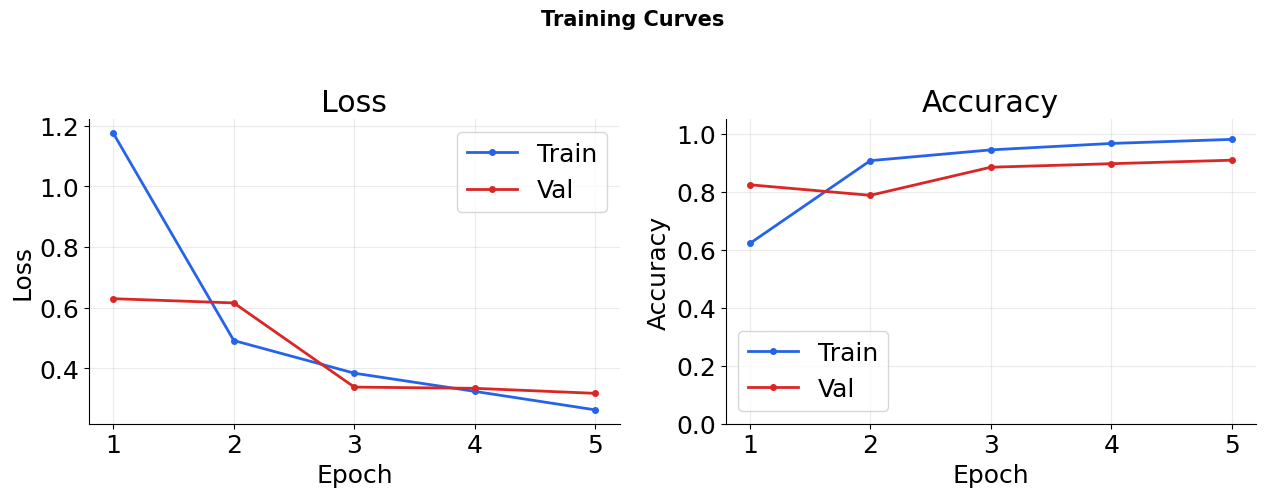

In [40]:
plot_training_results(kd_results)

In [44]:
test_acc, all_preds, all_labels = test_model_kd_cosine(student, test_loader=test_loader_10, device=device)

Running Inference on Test Set...


Test Accuracy: 0.9123


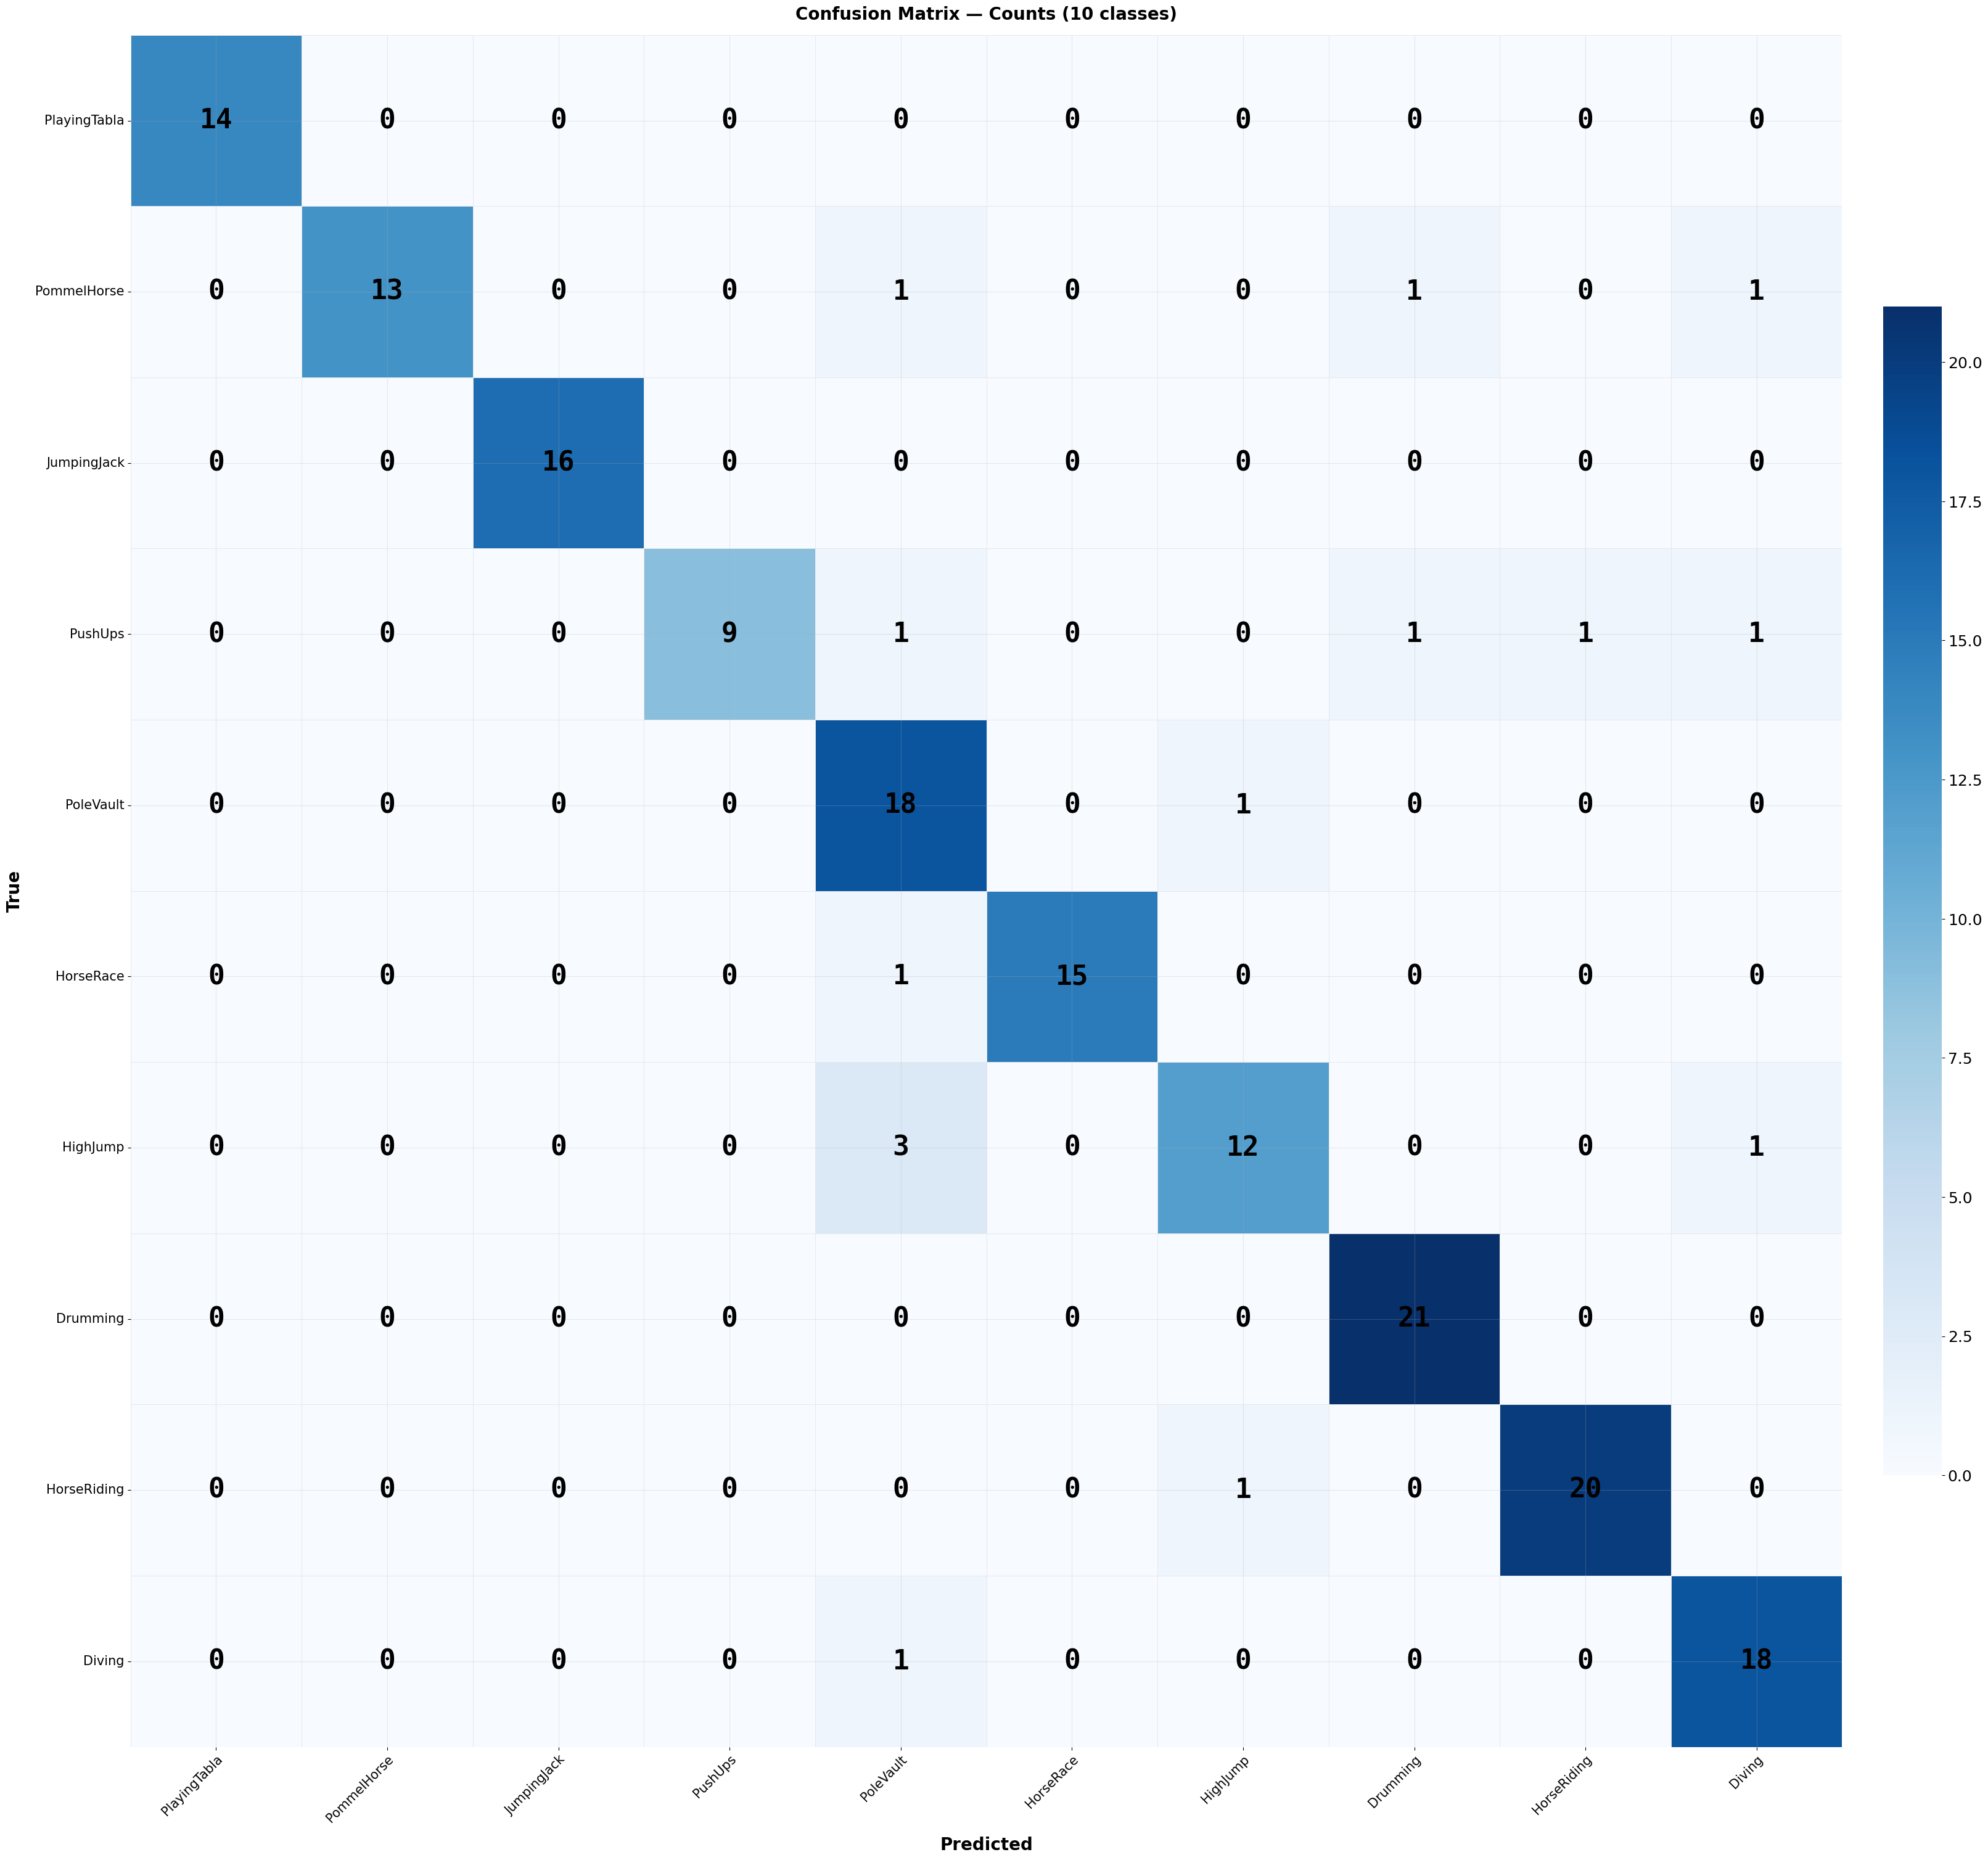

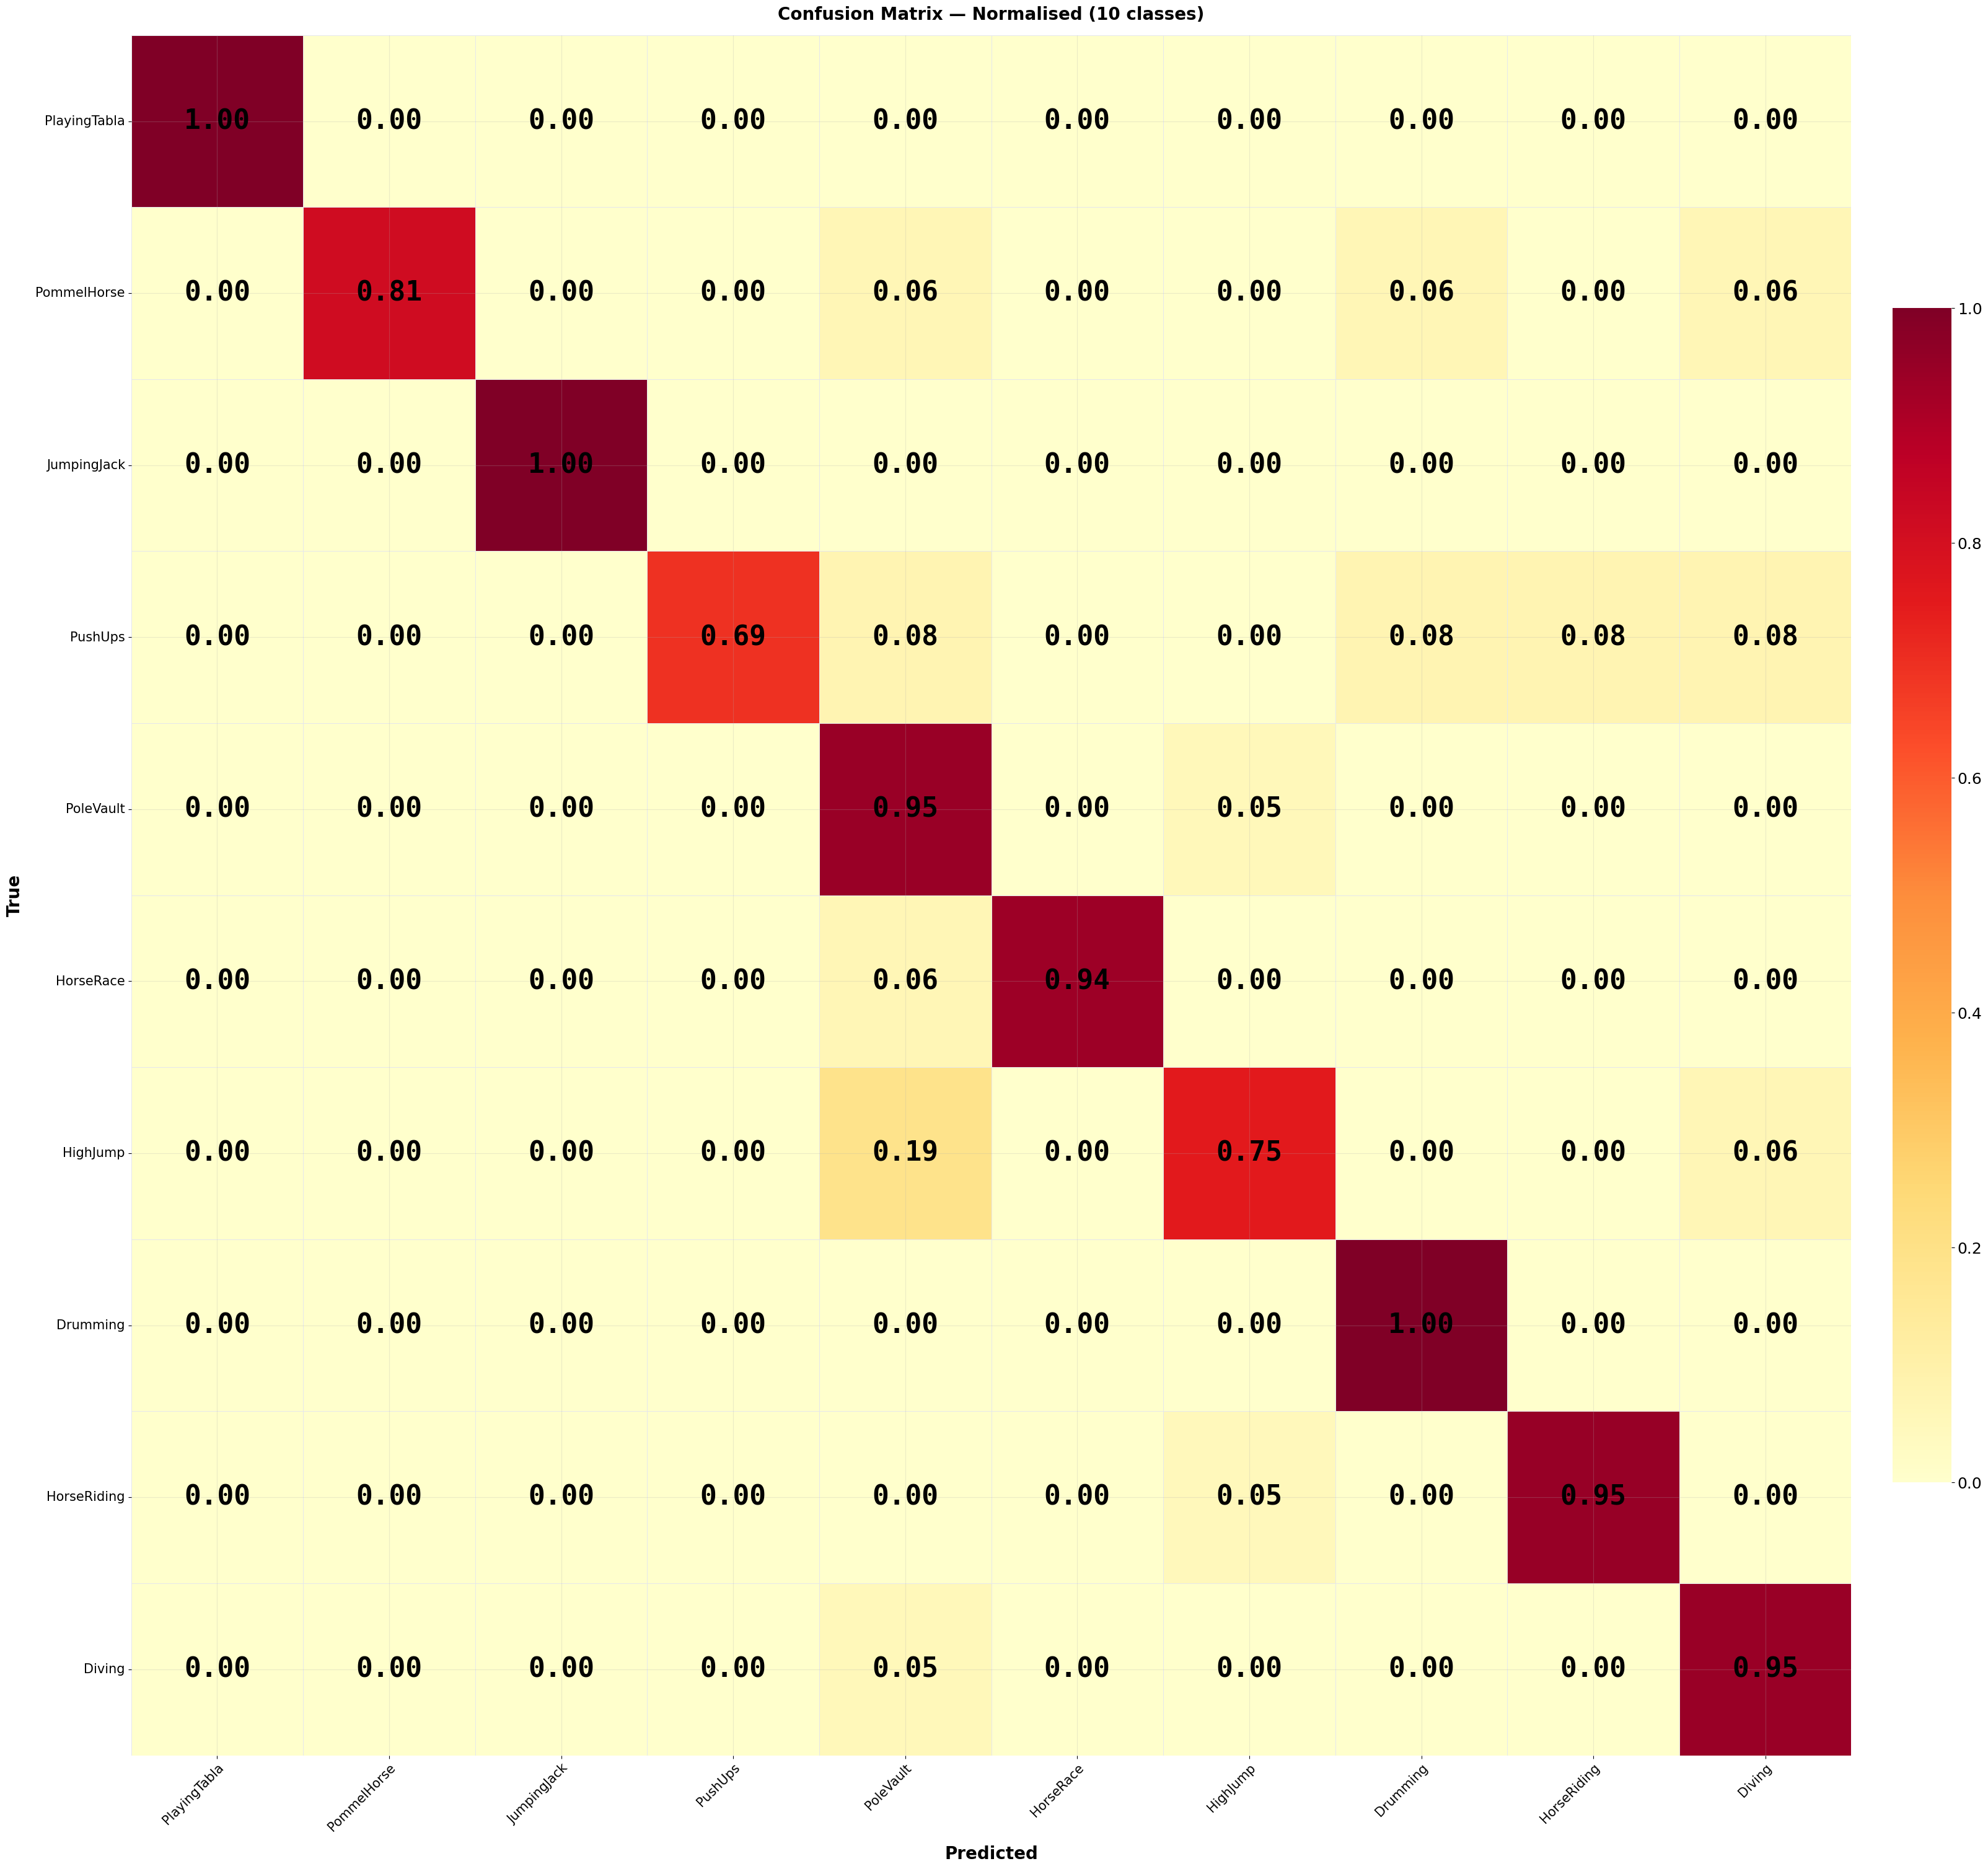

In [45]:
plot_confusion_matrix(all_labels, all_preds, num_classes=10, classes_list=SELECTED_CLASSES)